In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import minimize_scalar
from scipy.signal import savgol_filter


In [19]:
# Daten einlesen
dfA11 = pd.read_excel('data/xst.xlsx', sheet_name='A1.1')
dfA3 = pd.read_excel('data/xst.xlsx', sheet_name='A3')

# Vorverarbeitung
for df in [dfA11, dfA3]:
    df.dropna(subset=['beta', 'R'], inplace=True)
    df['beta'] = df['beta'].astype(float)
    df['R'] = df['R'].astype(float)
    df.sort_values('beta', inplace=True)
    df.reset_index(drop=True, inplace=True)

# Glätten mit Savitzky-Golay Filter
dfA11['R_smooth'] = savgol_filter(dfA11['R'], window_length=11, polyorder=3)
dfA3['R_smooth'] = savgol_filter(dfA3['R'], window_length=9, polyorder=3)

print(f"A1.1: {len(dfA11)} Punkte, Beta: {dfA11['beta'].min():.1f}-{dfA11['beta'].max():.1f}°")
print(f"A3:   {len(dfA3)} Punkte, Beta: {dfA3['beta'].min():.1f}-{dfA3['beta'].max():.1f}°")


A1.1: 231 Punkte, Beta: 2.0-25.0°
A3:   81 Punkte, Beta: 2.0-10.0°


In [20]:
dfA11.head()

# %% [markdown]
# ## Plot 1: Originalkurven im Vergleich


,beta,R,R_smooth
0,2.0,4.0,3.286713
1,2.1,2.0,3.391608
2,2.2,4.0,3.452214
3,2.3,3.0,3.469697
4,2.4,3.0,3.445221


In [21]:
# Plot-Style
plt.rcParams["text.usetex"] = True
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['legend.fontsize'] = 13


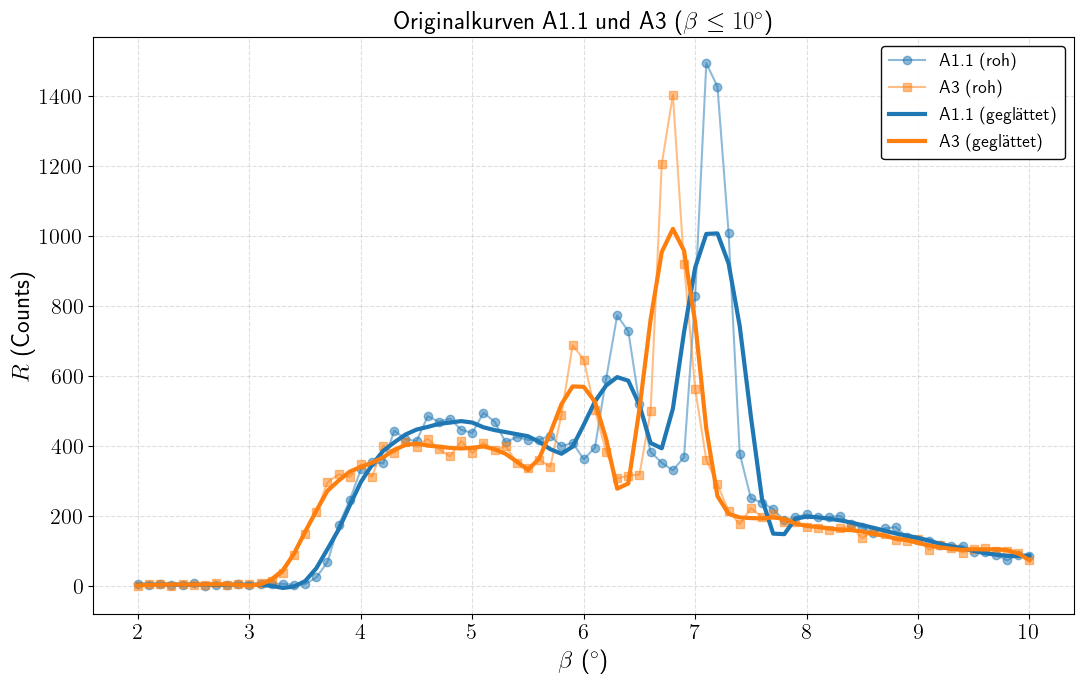

In [22]:
# Plot nur bis beta=10
fig, ax = plt.subplots(figsize=(11, 7))

# Filter data for beta <= 10
mask_A11 = dfA11['beta'] <= 10
mask_A3 = dfA3['beta'] <= 10

ax.plot(dfA11.loc[mask_A11, 'beta'], dfA11.loc[mask_A11, 'R'],
        marker='o', linewidth=1.5, markersize=6, label='A1.1 (roh)',
        alpha=0.5, color='#1f77b4')
ax.plot(dfA3.loc[mask_A3, 'beta'], dfA3.loc[mask_A3, 'R'],
        marker='s', linewidth=1.5, markersize=6, label='A3 (roh)',
        alpha=0.5, color='#ff7f0e')

# Geglättete Kurven
ax.plot(dfA11.loc[mask_A11, 'beta'], dfA11.loc[mask_A11, 'R_smooth'],
        linewidth=3, label='A1.1 (geglättet)', color='#1f77b4')
ax.plot(dfA3.loc[mask_A3, 'beta'], dfA3.loc[mask_A3, 'R_smooth'],
        linewidth=3, label='A3 (geglättet)', color='#ff7f0e')

ax.set_xlabel(r'$\beta$ ($^\circ$)', fontsize=18, fontweight='bold')
ax.set_ylabel(r'$R$ (Counts)', fontsize=18, fontweight='bold')
ax.set_title(r'Originalkurven A1.1 und A3 ($\beta \leq 10^\circ$)',
             fontsize=18, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=16)
ax.grid(True, alpha=0.4, linestyle='--', linewidth=0.8)
ax.legend(loc="best", frameon=True, fontsize=13, framealpha=0.95, edgecolor='black', fancybox=True)
plt.tight_layout()
plt.show()

fig.savefig("aufg7_originalkurven.svg", format="svg", bbox_inches='tight', dpi=150)

# %% [markdown]
# ## Shift-Berechnung: Cross-Correlation Methode


In [36]:
def calculate_shift_for_window(dfA11, dfA3, beta_min, beta_max,
                               shift_range=(-1.0, 1.0), n_test=200):
    """
    Berechnet optimalen Shift für ein Fenster mit Cross-Correlation.

    Positiver Shift = A3 nach rechts verschieben
    """
    # Fenster-Daten
    mask1 = (dfA11['beta'] >= beta_min) & (dfA11['beta'] <= beta_max)
    mask3 = (dfA3['beta'] >= beta_min) & (dfA3['beta'] <= beta_max)

    df1 = dfA11[mask1].copy()
    df3 = dfA3[mask3].copy()

    if len(df1) < 5 or len(df3) < 5:
        return np.nan, -1, None, None

    # Interpolation
    beta_grid = np.linspace(beta_min, beta_max, 500)
    f1 = interp1d(df1['beta'], df1['R_smooth'], kind='cubic',
                  bounds_error=False, fill_value='extrapolate')
    f3 = interp1d(df3['beta'], df3['R_smooth'], kind='cubic',
                  bounds_error=False, fill_value='extrapolate')

    # Teste Shifts
    shifts = np.linspace(shift_range[0], shift_range[1], n_test)
    correlations = []

    for shift in shifts:
        R1 = f1(beta_grid)
        R3 = f3(beta_grid - shift)  # Shift nach rechts

        valid = np.isfinite(R1) & np.isfinite(R3)
        if np.sum(valid) < 10:
            correlations.append(-1)
            continue

        # Normalisieren
        R1_norm = (R1[valid] - np.mean(R1[valid])) / np.std(R1[valid])
        R3_norm = (R3[valid] - np.mean(R3[valid])) / np.std(R3[valid])

        corr = np.corrcoef(R1_norm, R3_norm)[0, 1]
        correlations.append(corr)

    correlations = np.array(correlations)
    best_idx = np.argmax(correlations)
    optimal_shift = shifts[best_idx]
    max_corr = correlations[best_idx]

    return optimal_shift, max_corr, shifts, correlations


In [37]:
# Definiere 3 spezifische Fenster für die Analyse
windows = [
    (3.0, 4.0),   # Fenster 1: Anstiegsbereich (3-4°)
    (6.0, 7.0),   # Fenster 2: Erster Peak (6-7°)
    (6.4, 7.4),   # Fenster 3: Zweiter Peak / Hauptpeak (6.4-7.4°)
]

# Analysiere alle Fenster
results = []
print("FENSTER-ANALYSE (3 ausgewählte Bereiche):")
print("=" * 70)

for i, (beta_min, beta_max) in enumerate(windows):
    shift, corr, shifts_arr, corr_arr = calculate_shift_for_window(
        dfA11, dfA3, beta_min, beta_max
    )

    results.append({
        'window': (beta_min, beta_max),
        'shift': shift,
        'correlation': corr,
        'shifts': shifts_arr,
        'correlations': corr_arr
    })

    print(f"Fenster {i+1}: [{beta_min:.1f}, {beta_max:.1f}]° → "
          f"Δβ = {shift:+.4f}° (Korrelation: {corr:.4f})")


FENSTER-ANALYSE (3 ausgewählte Bereiche):
Fenster 1: [3.0, 4.0]° → Δβ = +0.2261° (Korrelation: 0.9916)
Fenster 2: [6.0, 7.0]° → Δβ = +0.3065° (Korrelation: 0.9379)
Fenster 3: [6.4, 7.4]° → Δβ = +0.2965° (Korrelation: 0.8927)


In [38]:
# Statistik
shifts_valid = np.array([r['shift'] for r in results if np.isfinite(r['shift'])])

mean_shift = np.mean(shifts_valid)
std_shift = np.std(shifts_valid, ddof=1)
median_shift = np.median(shifts_valid)

print("\n" + "=" * 70)
print("STATISTISCHE AUSWERTUNG:")
print("=" * 70)
print(f"Mittelwert:           Δβ = {mean_shift:+.4f}°")
print(f"Median:               Δβ = {median_shift:+.4f}°")
print(f"Standardabweichung:   u_β = {std_shift:.4f}°")
print(f"|Δβ|:                 {abs(mean_shift):.4f}°")
print()
print(f"Einzelwerte: {', '.join([f'{s:+.3f}°' for s in shifts_valid])}")
print("=" * 70)

# %% [markdown]
# ## Interpretation der Unsicherheit



STATISTISCHE AUSWERTUNG:
Mittelwert:           Δβ = +0.2764°
Median:               Δβ = +0.2965°
Standardabweichung:   u_β = 0.0438°
|Δβ|:                 0.2764°

Einzelwerte: +0.226°, +0.307°, +0.296°


In [39]:
print("\nINTERPRETATION:")
print("=" * 70)
print(f"Die Kurve A3 ist systematisch um etwa {mean_shift:+.4f}° verschoben.")
print(f"A3 liegt bei kleineren Beta-Werten → positive Korrektur nötig.")
print()
print(f"Die Streuung zwischen verschiedenen Fenstern beträgt u_β = {std_shift:.4f}°")
print(f"Dies ist die zusätzliche Winkelunsicherheit aus der Kristallorientierung.")
print()
print("Gesamtunsicherheit (quadratische Addition):")
u_device = 0.05  # Annahme für gerätebdingte Unsicherheit
u_total = np.sqrt(u_device**2 + std_shift**2)
print(f"  u_gesamt = sqrt(u_Gerät² + u_β²)")
print(f"  u_gesamt = sqrt({u_device}² + {std_shift:.4f}²)")
print(f"  u_gesamt = {u_total:.4f}°")
print("=" * 70)

# %% [markdown]
# ## Visualisierung: Korrelation vs. Shift



INTERPRETATION:
Die Kurve A3 ist systematisch um etwa +0.2764° verschoben.
A3 liegt bei kleineren Beta-Werten → positive Korrektur nötig.

Die Streuung zwischen verschiedenen Fenstern beträgt u_β = 0.0438°
Dies ist die zusätzliche Winkelunsicherheit aus der Kristallorientierung.

Gesamtunsicherheit (quadratische Addition):
  u_gesamt = sqrt(u_Gerät² + u_β²)
  u_gesamt = sqrt(0.05² + 0.0438²)
  u_gesamt = 0.0665°


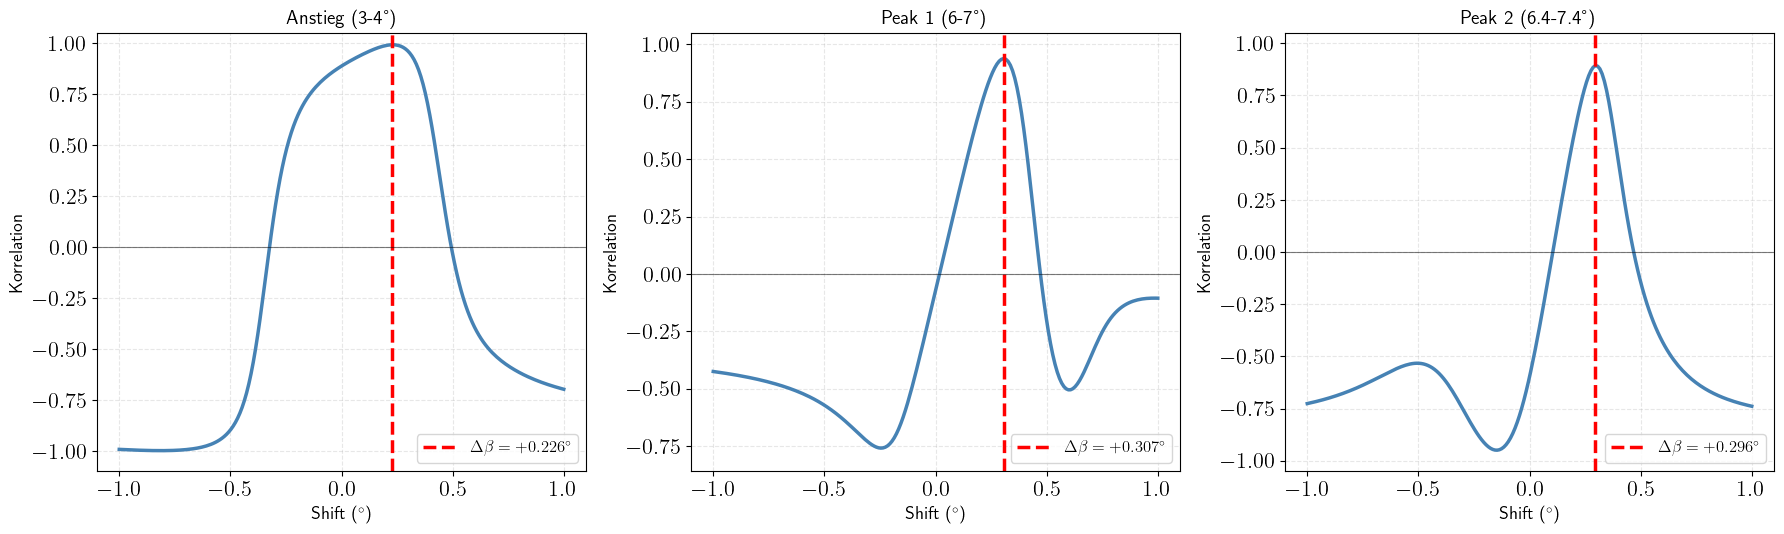

In [40]:
# Plot Korrelation für alle 3 Fenster
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

fenster_namen = ['Anstieg (3-4°)', 'Peak 1 (6-7°)', 'Peak 2 (6.4-7.4°)']

for i, (res, name) in enumerate(zip(results, fenster_namen)):
    ax = axes[i]
    ax.plot(res['shifts'], res['correlations'], linewidth=2.5, color='steelblue')
    ax.axvline(res['shift'], color='red', linestyle='--', linewidth=2.5,
              label=f"$\\Delta\\beta={res['shift']:+.3f}^\\circ$")
    ax.set_xlabel(r'Shift ($^\circ$)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Korrelation', fontsize=13, fontweight='bold')
    window = res['window']
    ax.set_title(f"{name}", fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(fontsize=12, loc='lower right')
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
    ax.set_ylim([min(res['correlations'])-0.1, 1.05])

plt.tight_layout()
plt.show()
fig.savefig('aufg7_correlation_analysis.svg', format='svg', bbox_inches='tight', dpi=150)
fig.savefig('aufg7_correlation_analysis.pdf', bbox_inches='tight', dpi=150)

# %% [markdown]
# ## Vorher/Nachher-Vergleich


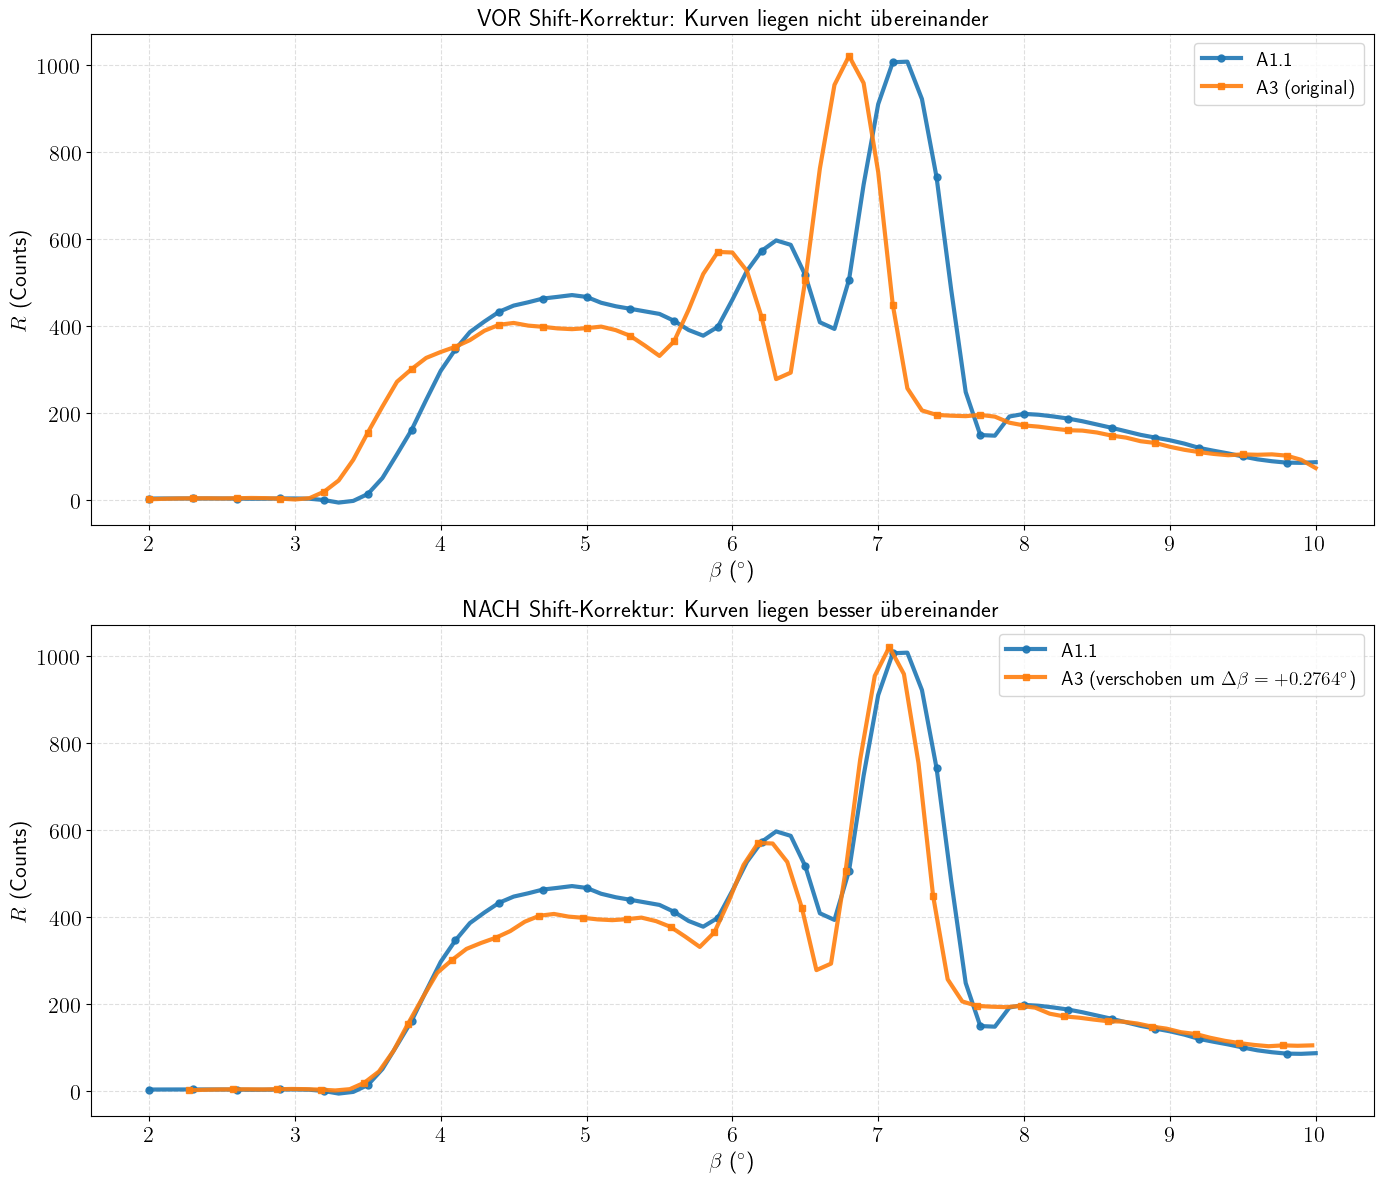

In [41]:
# Vergleichsplot mit optimalem Shift
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

beta_min, beta_max = 2.0, 10.0
mask1 = (dfA11['beta'] >= beta_min) & (dfA11['beta'] <= beta_max)
mask3 = (dfA3['beta'] >= beta_min) & (dfA3['beta'] <= beta_max)

# Plot 1: Vor Korrektur
ax1.plot(dfA11.loc[mask1, 'beta'], dfA11.loc[mask1, 'R_smooth'],
        linewidth=3, label='A1.1', alpha=0.9, color='#1f77b4',
        marker='o', markersize=5, markevery=3)
ax1.plot(dfA3.loc[mask3, 'beta'], dfA3.loc[mask3, 'R_smooth'],
        linewidth=3, label='A3 (original)', alpha=0.9, color='#ff7f0e',
        marker='s', markersize=5, markevery=3)

ax1.set_xlabel(r'$\beta$ ($^\circ$)', fontsize=16, fontweight='bold')
ax1.set_ylabel(r'$R$ (Counts)', fontsize=16, fontweight='bold')
ax1.set_title(r'VOR Shift-Korrektur: Kurven liegen nicht übereinander',
             fontsize=17, fontweight='bold')
ax1.grid(True, alpha=0.4, linestyle='--')
ax1.legend(fontsize=14)

# Plot 2: Nach Korrektur
dfA3_shifted = dfA3.copy()
dfA3_shifted['beta'] = dfA3['beta'] + mean_shift
mask3_shifted = (dfA3_shifted['beta'] >= beta_min) & (dfA3_shifted['beta'] <= beta_max)

ax2.plot(dfA11.loc[mask1, 'beta'], dfA11.loc[mask1, 'R_smooth'],
        linewidth=3, label='A1.1', alpha=0.9, color='#1f77b4',
        marker='o', markersize=5, markevery=3)
ax2.plot(dfA3_shifted.loc[mask3_shifted, 'beta'], dfA3_shifted.loc[mask3_shifted, 'R_smooth'],
        linewidth=3, label=f'A3 (verschoben um $\Delta\\beta={mean_shift:+.4f}^\circ$)',
        alpha=0.9, color='#ff7f0e', marker='s', markersize=5, markevery=3)

ax2.set_xlabel(r'$\beta$ ($^\circ$)', fontsize=16, fontweight='bold')
ax2.set_ylabel(r'$R$ (Counts)', fontsize=16, fontweight='bold')
ax2.set_title(r'NACH Shift-Korrektur: Kurven liegen besser übereinander',
             fontsize=17, fontweight='bold')
ax2.grid(True, alpha=0.4, linestyle='--')
ax2.legend(fontsize=14)

plt.tight_layout()
plt.show()

fig.savefig("aufg7_vorher_nachher.svg", format="svg", bbox_inches='tight', dpi=150)

# %% [markdown]
# ## Detail-Ansicht: Einzelne Fenster


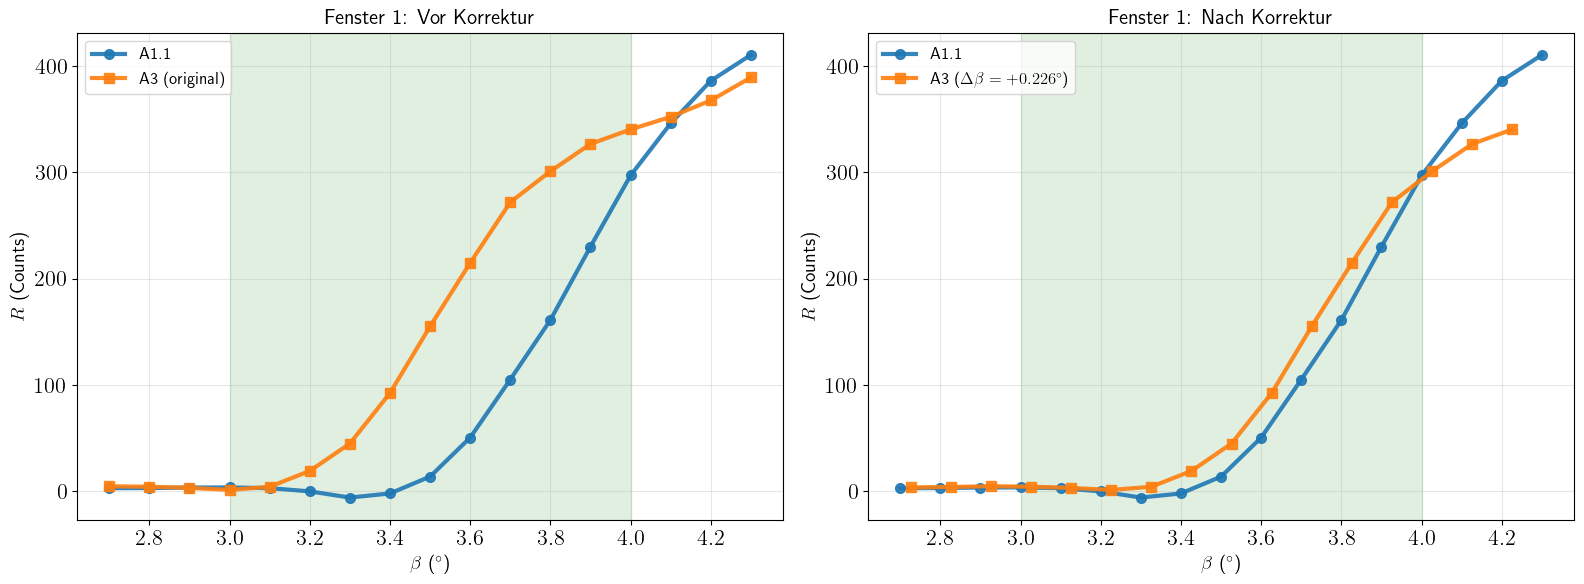

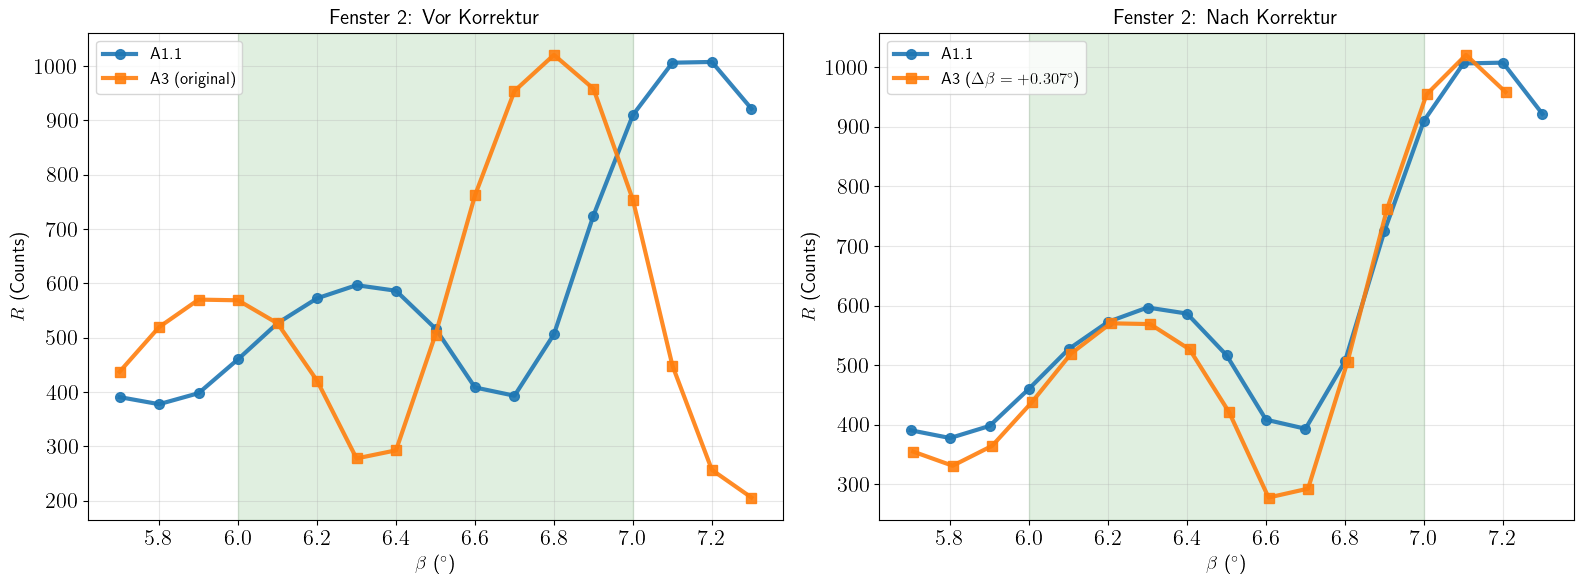

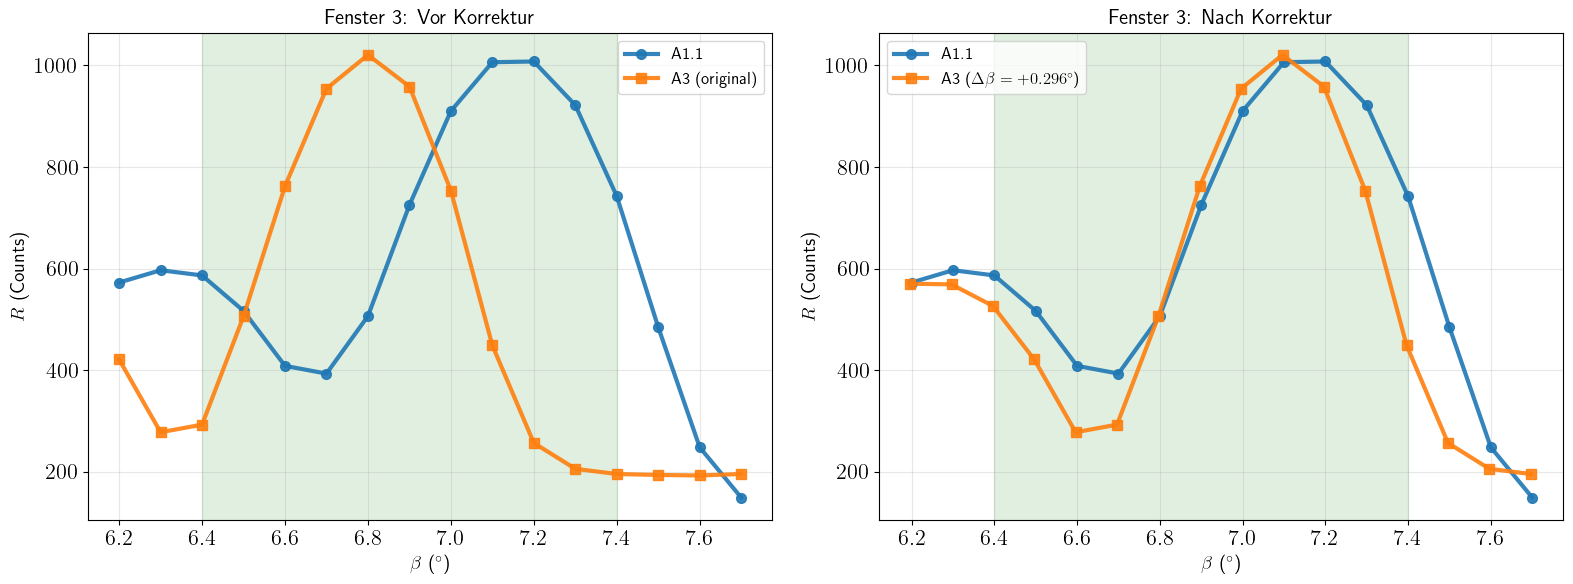

In [42]:
# Detailansicht für alle 3 Fenster
for i in range(len(windows)):
    res = results[i]
    window = res['window']
    beta_min, beta_max = window
    shift = res['shift']

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    padding = 0.3

    for ax, use_shift, title in zip(axes, [False, True],
                                     ['Vor Korrektur', 'Nach Korrektur']):
        mask1 = (dfA11['beta'] >= beta_min - padding) & (dfA11['beta'] <= beta_max + padding)

        if use_shift:
            dfA3_plot = dfA3.copy()
            dfA3_plot['beta'] = dfA3['beta'] + shift
            mask3 = (dfA3_plot['beta'] >= beta_min - padding) & (dfA3_plot['beta'] <= beta_max + padding)
            label3 = f'A3 ($\Delta\\beta={shift:+.3f}^\circ$)'
        else:
            dfA3_plot = dfA3
            mask3 = (dfA3_plot['beta'] >= beta_min - padding) & (dfA3_plot['beta'] <= beta_max + padding)
            label3 = 'A3 (original)'

        ax.plot(dfA11.loc[mask1, 'beta'], dfA11.loc[mask1, 'R_smooth'],
                linewidth=3, label='A1.1', marker='o', markersize=7,
                alpha=0.9, color='#1f77b4')
        ax.plot(dfA3_plot.loc[mask3, 'beta'], dfA3_plot.loc[mask3, 'R_smooth'],
                linewidth=3, label=label3, marker='s', markersize=7,
                alpha=0.9, color='#ff7f0e')

        ax.axvspan(beta_min, beta_max, alpha=0.12, color='green')
        ax.set_xlabel(r'$\beta$ ($^\circ$)', fontsize=14, fontweight='bold')
        ax.set_ylabel(r'$R$ (Counts)', fontsize=14, fontweight='bold')
        ax.set_title(f'Fenster {i+1}: {title}', fontsize=15, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=12)

    plt.tight_layout()
    plt.show()
    fig.savefig(f'aufg7_fenster_{i+1}_detail.svg', format='svg', bbox_inches='tight', dpi=150)

# %% [markdown]
# ## Zusammenfassung: Shift-Übersicht


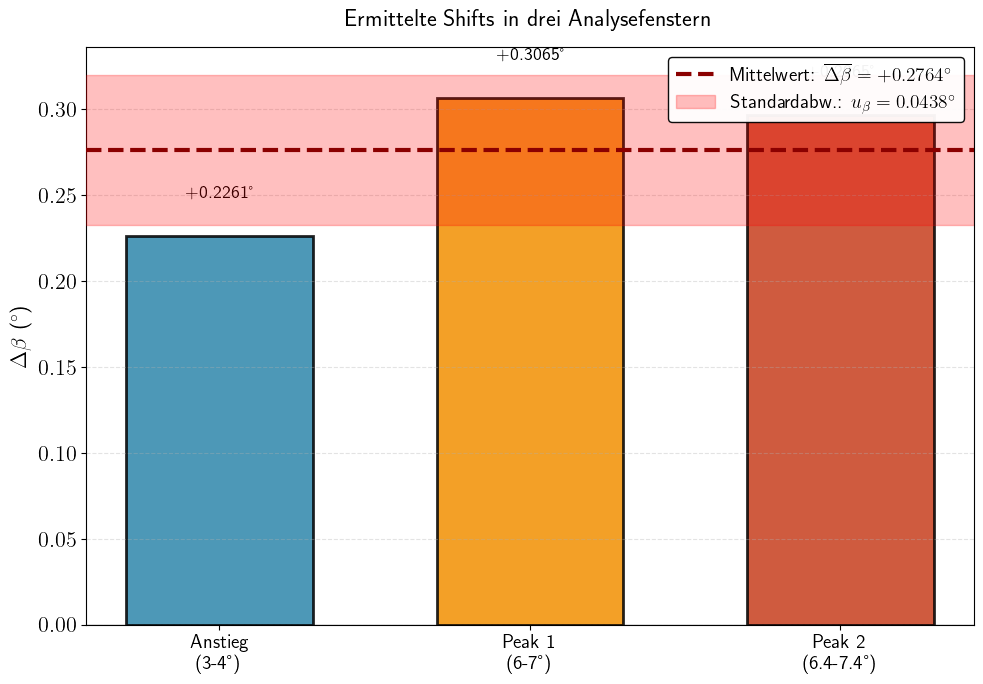

In [43]:
# Balkendiagramm mit allen Shifts
fig, ax = plt.subplots(figsize=(10, 7))

x_pos = np.arange(len(results))
shifts = [r['shift'] for r in results]
correlations = [r['correlation'] for r in results]

# Individuelle Farben für jedes Fenster
colors_bars = ['#2E86AB', '#F18F01', '#C73E1D']

bars = ax.bar(x_pos, shifts, color=colors_bars, alpha=0.85,
              edgecolor='black', linewidth=2, width=0.6)

# Beschriftung der Balken mit Werten
for i, (bar, shift_val) in enumerate(zip(bars, shifts)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{shift_val:+.4f}°', ha='center', va='bottom',
            fontsize=13, fontweight='bold')

# Mittelwert und Unsicherheit
ax.axhline(mean_shift, color='darkred', linestyle='--', linewidth=3,
          label=f'Mittelwert: $\\overline{{\\Delta\\beta}}={mean_shift:+.4f}^\\circ$',
          zorder=10)
ax.axhspan(mean_shift - std_shift, mean_shift + std_shift,
          alpha=0.25, color='red',
          label=f'Standardabw.: $u_\\beta = {std_shift:.4f}^\\circ$',
          zorder=5)
ax.axhline(0, color='black', linewidth=1, alpha=0.5)

# Beschriftung
fenster_labels = ['Anstieg\n(3-4°)', 'Peak 1\n(6-7°)', 'Peak 2\n(6.4-7.4°)']
ax.set_xticks(x_pos)
ax.set_xticklabels(fenster_labels, fontsize=14, fontweight='bold')
ax.set_ylabel(r'$\Delta\beta$ ($^\circ$)', fontsize=16, fontweight='bold')
ax.set_title('Ermittelte Shifts in drei Analysefenstern',
            fontsize=17, fontweight='bold', pad=15)
ax.grid(True, alpha=0.35, axis='y', linestyle='--', linewidth=0.8)
ax.legend(fontsize=14, loc='upper right', frameon=True,
         framealpha=0.95, edgecolor='black')

plt.tight_layout()
plt.show()
fig.savefig('aufg7_shift_summary.svg', format='svg', bbox_inches='tight', dpi=150)
fig.savefig('aufg7_shift_summary.pdf', bbox_inches='tight', dpi=150)

# %% [markdown]
# ## Ergebnis


In [44]:
print("\n" + "=" * 70)
print("FINALES ERGEBNIS")
print("=" * 70)
print()
print(f"Systematischer Shift:           Δβ = {mean_shift:+.4f}°")
print(f"Winkelunsicherheit (1σ):        u_β = {std_shift:.4f}°")
print(f"Median-Shift:                   Δβ_med = {median_shift:+.4f}°")
print()
print("BEDEUTUNG:")
print(f"  • Die unterschiedliche Kristallorientierung führt zu einer")
print(f"    zusätzlichen Winkelunsicherheit von u_β = {std_shift:.4f}°")
print(f"  • Diese muss quadratisch zur Geräteunsicherheit addiert werden")
print(f"  • A3 ist systematisch um ~{abs(mean_shift):.2f}° verschoben")
print()
print("=" * 70)

# %% [markdown]
# ## Gesamtunsicherheit berechnen



FINALES ERGEBNIS

Systematischer Shift:           Δβ = +0.2764°
Winkelunsicherheit (1σ):        u_β = 0.0438°
Median-Shift:                   Δβ_med = +0.2965°

BEDEUTUNG:
  • Die unterschiedliche Kristallorientierung führt zu einer
    zusätzlichen Winkelunsicherheit von u_β = 0.0438°
  • Diese muss quadratisch zur Geräteunsicherheit addiert werden
  • A3 ist systematisch um ~0.28° verschoben



In [ ]:
# Quadratische Addition
u_device = 0.05  # Geräteunsicherheit in Grad
u_beta = std_shift  # Unsicherheit aus Kristallorientierung
u_total = np.sqrt(u_device**2 + u_beta**2)

print("\nBERECHNUNG DER GESAMTUNSICHERHEIT:")
print("=" * 70)
print(f"Geräteunsicherheit:               u_Gerät = {u_device:.2f}°")
print(f"Kristallorientierungs-Unsicherheit: u_β   = {u_beta:.4f}°")
print()
print("Quadratische Addition:")
print(f"  u_gesamt = sqrt(u_Gerät² + u_β²)")
print(f"  u_gesamt = sqrt(({u_device})² + ({u_beta:.4f})²)")
print(f"  u_gesamt = sqrt({u_device**2:.4f} + {u_beta**2:.6f})")
print(f"  u_gesamt = {u_total:.4f}°")
print()
print(f"→ Für weitere Berechnungen wird u_β = {u_total:.4f}° verwendet")
print("=" * 70)

# %% [markdown]
# ## LaTeX-Output für Protokoll


In [ ]:
# Formatiere Ergebnisse für LaTeX
print("\n" + "=" * 70)
print("WERTE FÜR LATEX:")
print("=" * 70)
print()
print(f"Fenster 1 (3-4°):       Δβ_1 = {shifts[0]:+.4f}° = {shifts[0]:+.2f}°")
print(f"Fenster 2 (6-7°):       Δβ_2 = {shifts[1]:+.4f}° = {shifts[1]:+.2f}°")
print(f"Fenster 3 (6.4-7.4°):   Δβ_3 = {shifts[2]:+.4f}° = {shifts[2]:+.2f}°")
print()
print(f"Mittelwert:             \\overline{{Δβ}} = {mean_shift:+.4f}° = {mean_shift:+.2f}°")
print(f"Standardabweichung:     u_β = {std_shift:.4f}° = {std_shift:.2f}°")
print()
print(f"Geräteunsicherheit:     u_Gerät = {u_device:.2f}°")
print(f"Gesamtunsicherheit:     u_gesamt = {u_total:.4f}° = {u_total:.2f}°")
print()
print("=" * 70)
